In [100]:
import os
import boto3
import json
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import shape
import networkx as nx
import matplotlib.pyplot as plt
from botocore.exceptions import ClientError
import torch
import pickle

import mlflow
import mlflow.pytorch

In [93]:
s3_client = boto3.client('s3', region_name='us-west-2')
mlflow.set_tracking_uri("arn:aws:sagemaker:us-west-2:677276086662:mlflow-tracking-server/dawgsML")

BUCKET_NAME = 'snowml-shape'  
GOLD_LAYER_BUCKET = 'snowml-gold'

In [94]:
def list_s3_files(bucket, prefix=''):
    s3 = boto3.client('s3')
    paginator = s3.get_paginator('list_objects_v2')
    files = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        if 'Contents' in page:
            files.extend([obj['Key'] for obj in page['Contents']])
    return files

all_hucs = list_s3_files(BUCKET_NAME)
all_huc12s = [f for f in all_hucs if f.startswith('Huc12_')]

In [95]:
print(all_huc12s)
all_huc12s = all_huc12s[:1] + all_huc12s[4:]  
all_huc12s

['Huc12_in_17020009.geojson', 'Huc12_in_170200090105.geojson', 'Huc12_in_170200090210.geojson', 'Huc12_in_170200090302.geojson', 'Huc12_in_17030002.geojson', 'Huc12_in_17110005.geojson', 'Huc12_in_18040009.geojson']


['Huc12_in_17020009.geojson',
 'Huc12_in_17030002.geojson',
 'Huc12_in_17110005.geojson',
 'Huc12_in_18040009.geojson']

In [96]:
def download_geojson_from_s3(bucket, key):
    """Download GeoJSON from S3 bucket"""
    try:
        print(f"Downloading {key} from {bucket}...")
        response = s3_client.get_object(Bucket=bucket, Key=key)
        geojson_data = json.loads(response['Body'].read().decode('utf-8'))
        print(f"Successfully downloaded GeoJSON")
        return geojson_data
    except ClientError as e:
        print(f"Error downloading from S3: {e}")
        return None

def load_huc12_data(bucket, key):
    """Load HUC12 data as GeoDataFrame"""
    geojson_data = download_geojson_from_s3(bucket, key)
    if geojson_data:
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])
        gdf.set_crs(epsg=4326, inplace=True)
        return gdf
    return None

In [101]:
def generate_huc12_adjacency_matrix(gdf, use_geographic_adjacency=True):
    """
    Generate adjacency matrix for HUC12 watersheds based on boundary sharing.

    Parameters:
    - gdf: GeoDataFrame with HUC12 watersheds
    - use_geographic_adjacency: If True, add edges for watersheds that share boundaries

    Returns:
    - adj_matrix: Adjacency matrix (numpy array)
    - node_ids: List of HUC12 IDs corresponding to matrix rows/cols
    - coordinates: Centroid coordinates for each node
    """
    num_nodes = len(gdf)
    adj_matrix = np.zeros((num_nodes, num_nodes))

    # Get HUC12 IDs
    node_ids = gdf['huc_id'].tolist()

    # Project to UTM for all geometric operations
    gdf_projected = gdf.to_crs(epsg=32610)

    # Extract centroids for visualization
    centroids = gdf_projected.geometry.centroid
    coordinates = np.array([[c.x, c.y] for c in centroids])

    # Connect watersheds that share a boundary (geographic adjacency)
    if use_geographic_adjacency:
        print("Building adjacency based on shared boundaries...")
        for i in range(num_nodes):
            if i % 10 == 0:
                print(f"  Processing node {i}/{num_nodes}...")
            geom_i = gdf_projected.iloc[i].geometry
            for j in range(i+1, num_nodes):
                geom_j = gdf_projected.iloc[j].geometry
                if geom_i.touches(geom_j):
                    adj_matrix[i, j] = 1.0  # Edge weight for direct neighbors
                    adj_matrix[j, i] = 1.0

    print(f"Adjacency matrix created: {num_nodes}x{num_nodes}")
    print(f"Number of edges: {int(np.sum(adj_matrix > 0) / 2)}")

    return adj_matrix, node_ids, coordinates

def normalize(arr):
    """
    Min-max normalize a numpy array or PyTorch tensor to [0, 1].
    Handles NaNs by ignoring them in min/max calculation.
    """
    arr = np.array(arr)
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if arr_max - arr_min == 0:
        return np.zeros_like(arr)
    return (arr - arr_min) / (arr_max - arr_min)

def create_static_features(gdf, coordinates):
    """
    Create static node features for ST-GNN:
    - Normalized x, y coordinates
    - Watershed area (normalized)
    - Elevation (if available)

    Returns:
    - static_features: PyTorch tensor of shape (num_nodes, num_features)
    """
    num_nodes = len(gdf)

    # Project to UTM for area calculation
    gdf_projected = gdf.to_crs(epsg=32610)
    areas = gdf_projected.geometry.area.values

    # Extract features
    x_coords = coordinates[:, 0]
    y_coords = coordinates[:, 1]

    # Normalize
    x_normalized = normalize(x_coords)
    y_normalized = normalize(y_coords)
    area_normalized = normalize(areas)

    # Check for elevation or other attributes
    feature_list = [x_normalized, y_normalized, area_normalized]
    feature_names = ['x_coord', 'y_coord', 'area']

    # Stack features
    features = np.column_stack(feature_list)

    # Convert to PyTorch tensor
    static_features = torch.tensor(features, dtype=torch.float32)

    print(f"Static features shape: {static_features.shape}")
    print(f"Features: {feature_names}")

    return static_features

def visualize_stgnn_graph(adj_matrix, coordinates, node_ids, gdf):
    """Visualize the ST-GNN graph structure"""
    # Project for plotting
    gdf_projected = gdf.to_crs(epsg=32610)
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    # Plot 1: Geographic view with edges
    gdf_projected.plot(ax=ax1, edgecolor='black', facecolor='lightblue', alpha=0.5)

    # Draw edges on geographic map (only boundary connections)
    for i in range(len(adj_matrix)):
        for j in range(i+1, len(adj_matrix)):
            if adj_matrix[i, j] > 0:
                x_coords = [coordinates[i, 0], coordinates[j, 0]]
                y_coords = [coordinates[i, 1], coordinates[j, 1]]
                ax1.plot(x_coords, y_coords, color='red', alpha=0.3, linewidth=1)

    # Plot centroids
    ax1.scatter(coordinates[:, 0], coordinates[:, 1], c='red', s=50, zorder=5, label='HUC12 Centroids')
    ax1.set_title('HUC12 Watersheds with Boundary Adjacency')
    ax1.set_xlabel('Easting (m)')
    ax1.set_ylabel('Northing (m)')
    ax1.legend()

    plt.tight_layout()
    return fig

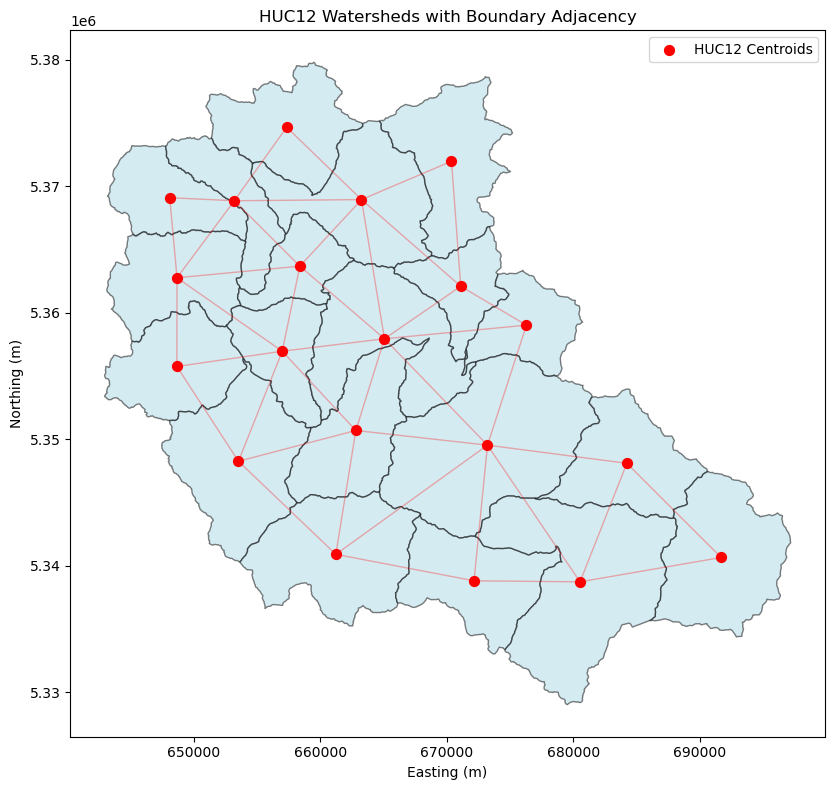

In [ ]:
N = 20 
subset_indices = list(range(N))

# Subset the adjacency matrix, coordinates, node_ids, and gdf
adj_matrix_sub = adj_matrix[np.ix_(subset_indices, subset_indices)]
coordinates_sub = coordinates[subset_indices]
node_ids_sub = [node_ids[i] for i in subset_indices]
gdf_sub = gdf_huc12.iloc[subset_indices]

# Visualize a subgraph 
fig = visualize_stgnn_graph(adj_matrix_sub, coordinates_sub, node_ids_sub, gdf_sub)
plt.show()

In [82]:
gdfs = []
for HUC12_KEY in all_huc12s:
    gdf = load_huc12_data(BUCKET_NAME, HUC12_KEY)
    if gdf is not None:
        gdfs.append(gdf)

gdf_huc12 = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

Successfully downloaded GeoJSON
Successfully downloaded GeoJSON
Successfully downloaded GeoJSON
Successfully downloaded GeoJSON


In [83]:
huc12s = gdf_huc12['huc_id'].tolist()

In [60]:
len(huc12s)

172

Creating ST-GNN Graph Structure...
Building adjacency based on shared boundaries...
  Processing node 0/172...
  Processing node 10/172...
  Processing node 20/172...
  Processing node 30/172...
  Processing node 40/172...
  Processing node 50/172...
  Processing node 60/172...
  Processing node 70/172...
  Processing node 80/172...
  Processing node 90/172...
  Processing node 100/172...
  Processing node 110/172...
  Processing node 120/172...
  Processing node 130/172...
  Processing node 140/172...
  Processing node 150/172...
  Processing node 160/172...
  Processing node 170/172...
Adjacency matrix created: 172x172
Number of edges: 402
Static features shape: torch.Size([172, 3])
Features: ['x_coord', 'y_coord', 'area']


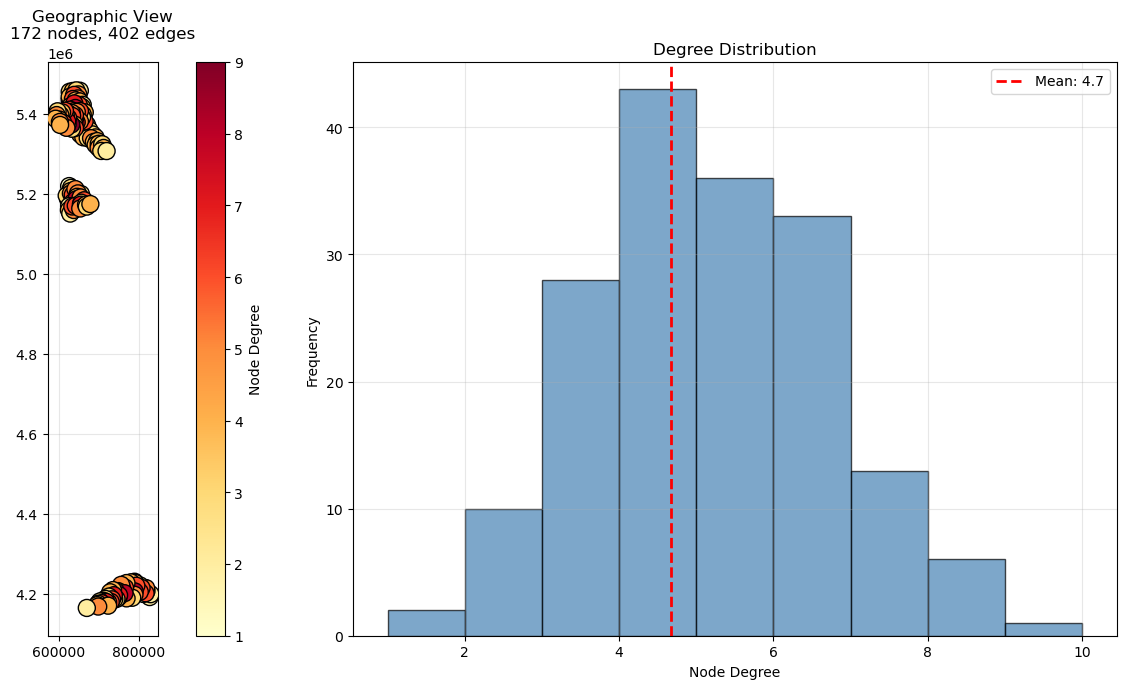


Graph construction complete!


In [99]:
# Generate ST-GNN adjacency matrix and features
print("Creating ST-GNN Graph Structure...")

# Generate adjacency matrix (boundary sharing only)
adj_matrix, node_ids, coordinates = generate_huc12_adjacency_matrix(gdf_huc12)

# Create static features
static_features = create_static_features(gdf_huc12, coordinates)

# Visualize
fig = visualize_stgnn_graph(adj_matrix, coordinates, node_ids, gdf_huc12)
plt.show()

# Save graph data
#metadata = save_stgnn_graph(adj_matrix, static_features, node_ids, coordinates, output_dir='../data')

print("\nGraph construction complete!")

# Download Metadata From the Gold Layer 

In [89]:
files = list_s3_files(GOLD_LAYER_BUCKET)

In [97]:
def download_all_s3_files(bucket, output_dir='./s3_downloads'):
    """
    Download all files from an S3 bucket to a local directory.
    """
    s3 = boto3.client('s3')
    os.makedirs(output_dir, exist_ok=True)
    paginator = s3.get_paginator('list_objects_v2')
    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            key = obj['Key']
            local_path = os.path.join(output_dir, os.path.basename(key))
            try:
                s3.download_file(bucket, key, local_path)
                print(f"Downloaded: {key} -> {local_path}")
            except Exception as e:
                print(f"Failed to download {key}: {e}")

download_all_s3_files(GOLD_LAYER_BUCKET, output_dir='st_gnn_data/metadata')

Downloaded: Snow_Types.csv -> st_gnn_data/metadata/Snow_Types.csv
Downloaded: Snow_Types_Region.csv -> st_gnn_data/metadata/Snow_Types_Region.csv
Downloaded: mean_pr_in_160401010101.csv -> st_gnn_data/metadata/mean_pr_in_160401010101.csv
Downloaded: mean_pr_in_160401010102.csv -> st_gnn_data/metadata/mean_pr_in_160401010102.csv
Downloaded: mean_pr_in_160401010103.csv -> st_gnn_data/metadata/mean_pr_in_160401010103.csv
Downloaded: mean_pr_in_160401010104.csv -> st_gnn_data/metadata/mean_pr_in_160401010104.csv
Downloaded: mean_pr_in_160401010105.csv -> st_gnn_data/metadata/mean_pr_in_160401010105.csv
Downloaded: mean_pr_in_160401010201.csv -> st_gnn_data/metadata/mean_pr_in_160401010201.csv
Downloaded: mean_pr_in_160401010202.csv -> st_gnn_data/metadata/mean_pr_in_160401010202.csv
Downloaded: mean_pr_in_160401010203.csv -> st_gnn_data/metadata/mean_pr_in_160401010203.csv
Downloaded: mean_pr_in_160401010204.csv -> st_gnn_data/metadata/mean_pr_in_160401010204.csv
Downloaded: mean_pr_in_160

KeyboardInterrupt: 

In [65]:
for huc in huc12s:
    matching_files = [fname for fname in files if huc in fname]
    print(f"HUC12 {huc} found in files: {matching_files}")

HUC12 170200090101 found in files: ['mean_pr_in_170200090101.csv', 'mean_pr_in_170200090101_append.csv', 'mean_rmax_in_170200090101.csv', 'mean_rmax_in_170200090101_append.csv', 'mean_rmin_in_170200090101.csv', 'mean_rmin_in_170200090101_append.csv', 'mean_srad_in_170200090101.csv', 'mean_srad_in_170200090101_append.csv', 'mean_swe_in_170200090101.csv', 'mean_swe_ucla_2_in_170200090101.csv', 'mean_tmmn_in_170200090101.csv', 'mean_tmmn_in_170200090101_append.csv', 'mean_tmmx_in_170200090101.csv', 'mean_tmmx_in_170200090101_append.csv', 'mean_vs_in_170200090101.csv', 'mean_vs_in_170200090101_append.csv']
HUC12 170200090102 found in files: ['mean_pr_in_170200090102.csv', 'mean_pr_in_170200090102_append.csv', 'mean_rmax_in_170200090102.csv', 'mean_rmax_in_170200090102_append.csv', 'mean_rmin_in_170200090102.csv', 'mean_rmin_in_170200090102_append.csv', 'mean_srad_in_170200090102.csv', 'mean_srad_in_170200090102_append.csv', 'mean_swe_in_170200090102.csv', 'mean_swe_ucla_2_in_170200090102.c

In [86]:
df = pd.read_csv('st_gnn_data/metadata/mean_pr_in_170200090101.csv')
df2 = pd.read_csv('st_gnn_data/metadata/mean_pr_in_171100050101_append.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'st_gnn_data/metadata/mean_pr_in_170200090101.csv'

In [66]:
features = set()
for i in files:
    feature = '_'.join(i.split('_')[:2])
    features.add(feature)

features=list(features)
features

['mean_rmax',
 'mean_rmin',
 'Snow_Types',
 'mean_tmmn',
 'mean_swe',
 'Snow_Types.csv',
 'mean_tmmx',
 'mean_pr',
 'mean_srad',
 'mean_vs']

In [17]:
sorted(features)[3:]

['mean_rmax',
 'mean_rmin',
 'mean_srad',
 'mean_swe',
 'mean_tmmn',
 'mean_tmmx',
 'mean_vs']

In [18]:
metadata_files = []
for id in huc12s:
    for feature in sorted(features)[3:]:
        key = f"{feature}_in_{id}.csv"
        metadata_files.append(key)
        print(key)

def download_s3_files(bucket, keys, output_dir='./metadata'):
    """
    Download a list of files from S3 to a local directory.
    """
    s3 = boto3.client('s3')
    os.makedirs(output_dir, exist_ok=True)
    for key in keys:
        local_path = os.path.join(output_dir, os.path.basename(key))
        try:
            s3.download_file(bucket, key, local_path)
            print(f"Downloaded: {key} -> {local_path}")
        except Exception as e:
            print(f"Failed to download {key}: {e}")

download_s3_files(GOLD_LAYER_BUCKET, metadata_files, output_dir='../st_gnn_data/metadata')

mean_rmax_in_171100050101.csv
mean_rmin_in_171100050101.csv
mean_srad_in_171100050101.csv
mean_swe_in_171100050101.csv
mean_tmmn_in_171100050101.csv
mean_tmmx_in_171100050101.csv
mean_vs_in_171100050101.csv
mean_rmax_in_171100050102.csv
mean_rmin_in_171100050102.csv
mean_srad_in_171100050102.csv
mean_swe_in_171100050102.csv
mean_tmmn_in_171100050102.csv
mean_tmmx_in_171100050102.csv
mean_vs_in_171100050102.csv
mean_rmax_in_171100050201.csv
mean_rmin_in_171100050201.csv
mean_srad_in_171100050201.csv
mean_swe_in_171100050201.csv
mean_tmmn_in_171100050201.csv
mean_tmmx_in_171100050201.csv
mean_vs_in_171100050201.csv
mean_rmax_in_171100050202.csv
mean_rmin_in_171100050202.csv
mean_srad_in_171100050202.csv
mean_swe_in_171100050202.csv
mean_tmmn_in_171100050202.csv
mean_tmmx_in_171100050202.csv
mean_vs_in_171100050202.csv
mean_rmax_in_171100050203.csv
mean_rmin_in_171100050203.csv
mean_srad_in_171100050203.csv
mean_swe_in_171100050203.csv
mean_tmmn_in_171100050203.csv
mean_tmmx_in_1711000502

In [12]:
print(os.listdir('st_gnn_data/metadata'))

['mean_vs_in_171100050701.csv', 'mean_rmin_in_171100050804.csv', 'mean_rmax_in_171100050503.csv', 'mean_srad_in_171100050605.csv', 'mean_tmmn_in_171100050801.csv', 'mean_rmax_in_171100050701.csv', 'mean_tmmx_in_171100050805.csv', 'mean_vs_in_171100050503.csv', 'mean_swe_in_171100050402.csv', 'mean_vs_in_171100050305.csv', 'mean_srad_in_171100050201.csv', 'mean_rmax_in_171100050305.csv', 'mean_tmmx_in_171100051104.csv', 'mean_rmax_in_171100050304.csv', 'mean_rmin_in_171100051104.csv', 'mean_tmmn_in_171100051101.csv', 'mean_vs_in_171100050304.csv', 'mean_swe_in_171100050403.csv', 'mean_tmmx_in_171100050804.csv', 'mean_vs_in_171100050502.csv', 'mean_swe_in_171100050601.csv', 'mean_srad_in_171100050604.csv', 'mean_rmax_in_171100050502.csv', 'mean_rmin_in_171100050805.csv', 'mean_vs_in_171100050702.csv', 'mean_swe_in_171100050603.csv', 'mean_srad_in_171100050606.csv', 'mean_tmmn_in_171100050802.csv', 'mean_rmax_in_171100050702.csv', 'mean_swe_in_171100050401.csv', 'mean_srad_in_171100050404

In [35]:
def load_huc_metadata_aligned(metadata_dir, huc_ids, feature_names):
    """
    Load and align time series metadata for each HUC and feature by timestamp.
    Returns a tensor of shape [num_hucs, num_features, num_timesteps] and the master timestamp index.
    """
    # 1. Gather all unique timestamps
    all_timestamps = set()
    for huc in huc_ids:
        for feature in feature_names:
            fname = f"{feature}_in_{huc}.csv"
            fpath = os.path.join(metadata_dir, fname)
            if os.path.exists(fpath):
                df = pd.read_csv(fpath)
                all_timestamps.update(df.iloc[:, 0].astype(str).tolist())
    master_index = sorted(all_timestamps)

    # 2. Align all series to the master index
    all_data = []
    for huc in huc_ids:
        huc_data = []
        for feature in feature_names:
            fname = f"{feature}_in_{huc}.csv"
            fpath = os.path.join(metadata_dir, fname)
            if os.path.exists(fpath):
                df = pd.read_csv(fpath)
                df = df.iloc[:, :2]  # Only timestamp and value
                df.columns = ['timestamp', 'value']
                df['timestamp'] = df['timestamp'].astype(str)
                df = df.set_index('timestamp').reindex(master_index)
                ts = df['value'].values.astype(float)
            else:
                ts = np.full(len(master_index), np.nan)
            huc_data.append(ts)
        all_data.append(huc_data)
    # 3. Convert to tensor
    return torch.tensor(np.array(all_data), dtype=torch.float32), master_index

In [36]:
metadata_dir = 'st_gnn_data/metadata'
huc_ids = huc12s
feature_names = sorted(features)[3:]

# Load all metadata as a tensor
dynamic_features, master_index = load_huc_metadata_aligned(metadata_dir, huc_ids, feature_names)
print(dynamic_features.shape)  # Should be [num_hucs, num_features, num_timesteps]

torch.Size([57, 7, 15067])


In [37]:
seq_len = 30

# Create sliding windows for input and target
def create_sliding_windows(data, seq_len, target_feature_idx=0):
    num_nodes, num_features, num_timesteps = data.shape
    num_samples = num_timesteps - seq_len
    X, y = [], []
    for i in range(num_samples):
        window = data[:, :, i:i+seq_len]  # [num_nodes, num_features, seq_len]
        window = window.permute(1, 0, 2)  # [num_features, num_nodes, seq_len]
        X.append(window)
        # Target: SWE at next timestep (feature 0)
        y.append(data[:, target_feature_idx, i+seq_len])  # [num_nodes]
    return torch.stack(X), torch.stack(y)


In [38]:
dynamic_features = torch.nan_to_num(dynamic_features, nan=0.0)

X, y = create_sliding_windows(dynamic_features, seq_len)
adj_matrix = torch.tensor(adj_matrix, dtype=torch.float32)  # Ensure it's a torch tensor

print(X.shape)  # [num_samples, num_features, num_nodes, seq_len]
print(y.shape)  # [num_samples, num_nodes]
print(adj_matrix.shape)  # [num_nodes, num_nodes]

torch.Size([15037, 7, 57, 30])
torch.Size([15037, 57])
torch.Size([57, 57])


In [23]:
from train_model import train_swe_model

In [ ]:
mlflow.set_experiment("STGNN_SWE_HUC12_in_17110005")
model = train_swe_model(X, y, adj_matrix, num_epochs=20, batch_size=32, seq_len=30)

Epoch 1, Loss: 407.6854
Epoch 2, Loss: 181.9864
Epoch 3, Loss: 139.1035
Epoch 4, Loss: 106.3999
Epoch 5, Loss: 96.7128
Epoch 6, Loss: 91.0994
Epoch 7, Loss: 91.3693
Epoch 8, Loss: 86.6478
Epoch 9, Loss: 88.4717
Epoch 10, Loss: 83.7035
Epoch 11, Loss: 85.5150
Epoch 12, Loss: 83.8346
Epoch 13, Loss: 82.8915
Epoch 14, Loss: 82.9707
Epoch 15, Loss: 82.7417
Epoch 16, Loss: 82.9189
Epoch 17, Loss: 80.6280
Epoch 18, Loss: 81.7119
Epoch 19, Loss: 81.7633
Epoch 20, Loss: 79.5196


In [45]:
mlflow.set_tracking_uri("SnowML/src/snowML/STGNN/st_gnn_data/mlruns")
mlflow.set_experiment("STGNN_SWE_HUC12_in_17110005")
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("STGNN_SWE_HUC12_in_17110005")
artifact_location = "s3://wi2026-snowml-mlflow/mlflow-artifacts/"
model = train_swe_model(X, y, adj_matrix, num_epochs=5, batch_size=32, seq_len=30)

/opt/anaconda3/envs/snowml/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/01/26 17:05:41 INFO mlflow.tracking.fluent: Experiment with name 'STGNN_SWE_HUC12_in_17110005' does not exist. Creating a new experiment.
/Users/riyosha/UW_MSDS/capstone/SnowML/src/snowML/STGNN/train_model.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adj = torch.tensor(adj_matrix, d

Epoch 1, Loss: 518.1292
Epoch 2, Loss: 186.4158
Epoch 3, Loss: 146.2107
Epoch 4, Loss: 109.2723
Epoch 5, Loss: 99.8859
